In [24]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')

def in_active_volume(x_start, x_end, y_start, y_end, z_start, z_end):
    return max(abs(x_start), abs(z_start), abs(x_end), abs(z_end)) <= 30 and max(abs(y_start), abs(y_end)) <= 25

def in_signal_volume(x_start, x_end, y_start, y_end, z_start, z_end):
    return max(abs(x_start), abs(z_start), abs(x_end), abs(z_end)) <= 25 and max(abs(y_start), abs(y_end)) <= 20

def in_fiducial_volume(x_start, x_end, y_start, y_end, z_start, z_end):
    return max(abs(x_start), abs(z_start), abs(x_end), abs(z_end)) <= 20 and max(abs(y_start), abs(y_end)) <= 15

In [26]:
# Calculate longest and highest energy deposition trajectories per event, as well as energy deposited in fiducial, signal, and active volumes per event
data_energies = []
edata_particles = {}
data_lengths = []
ldata_particles = {}
data_totalenergy = {0: [0, 0, 0]}

temp_particles = {}
temp_energies = {}
temp_lengths = {}

event_id = f['segments'][0]['event_id']
for seg in f['segments']:
    if seg['event_id'] > event_id:
        greatest_energy_dep = 0
        longest_path = 0
        
        for traj_id in temp_particles:
            if temp_energies[traj_id] > temp_energies[greatest_energy_dep]:
                greatest_energy_dep = traj_id

            if temp_lengths[traj_id] > temp_lengths[longest_path]:
                longest_path = traj_id

        if (edata_particles.get(temp_particles[greatest_energy_dep])):
            edata_particles[temp_particles[greatest_energy_dep]] += 1
        else:
            edata_particles[temp_particles[greatest_energy_dep]] = 1

        if (ldata_particles.get(temp_particles[longest_path])):
            ldata_particles[temp_particles[longest_path]] += 1
        else:
            ldata_particles[temp_particles[longest_path]] = 1

        data_energies.append(temp_energies[greatest_energy_dep])
        data_lengths.append(temp_lengths[longest_path])
        temp_particles = {}
        temp_energies = {}
        temp_lengths = {}
        
        event_id = seg['event_id']
        data_totalenergy[event_id] = [0, 0, 0]

    data_totalenergy[event_id][2] += seg['dE']
    if in_fiducial_volume(seg['x_start'], seg['x_end'], seg['y_start'], seg['y_end'], seg['z_start'], seg['z_end']):
        data_totalenergy[event_id][0] += seg['dE']
        data_totalenergy[event_id][1] += seg['dE']
    elif in_signal_volume(seg['x_start'], seg['x_end'], seg['y_start'], seg['y_end'], seg['z_start'], seg['z_end']):
        data_totalenergy[event_id][1] += seg['dE']
    
    if temp_particles.get(seg['traj_id']):
        temp_energies[seg['traj_id']] += seg['dE']
        temp_lengths[seg['traj_id']] += seg['dx']
    else:
        temp_particles[seg['traj_id']] = seg['pdg_id']
        temp_energies[seg['traj_id']] = seg['dE']
        temp_lengths[seg['traj_id']] = seg['dx']

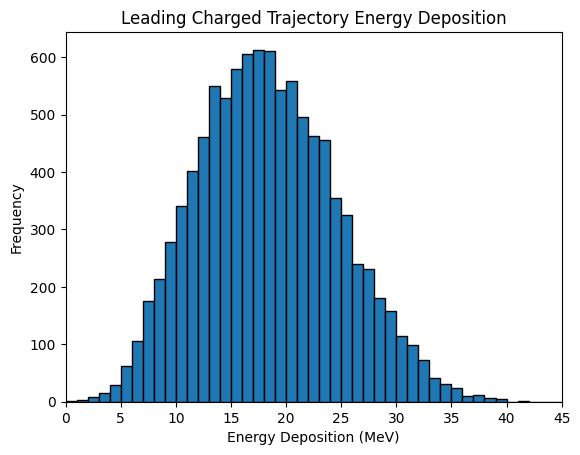

In [53]:
# Leading charged trajectory energy deposition plot

# Define bins
bins = np.arange(0, 46, 1)
plt.hist(data_energies, bins=bins, edgecolor='black')
plt.xlim(0, 45)

# Axis labels
plt.xlabel('Energy Deposition (MeV)')
plt.ylabel('Frequency')
plt.title('Leading Charged Trajectory Energy Deposition')

plt.show()

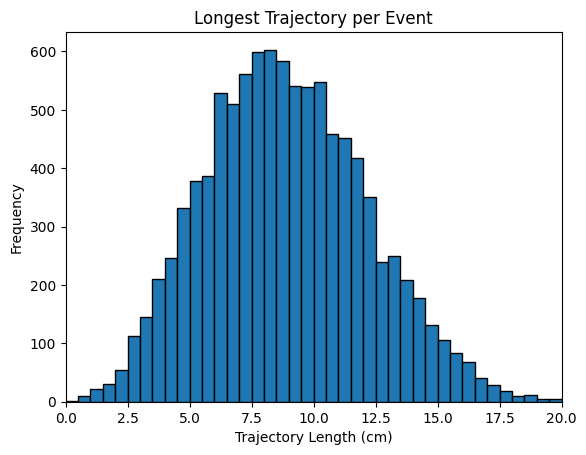

In [54]:
# Longest trajectory plot

# Define bins
bins = np.arange(0, 20.5, 0.5)
plt.hist(data_lengths, bins=bins, edgecolor='black')
plt.xlim(0, 20)

# Axis labels
plt.xlabel('Trajectory Length (cm)')
plt.ylabel('Frequency')
plt.title('Longest Trajectory per Event')

plt.show()

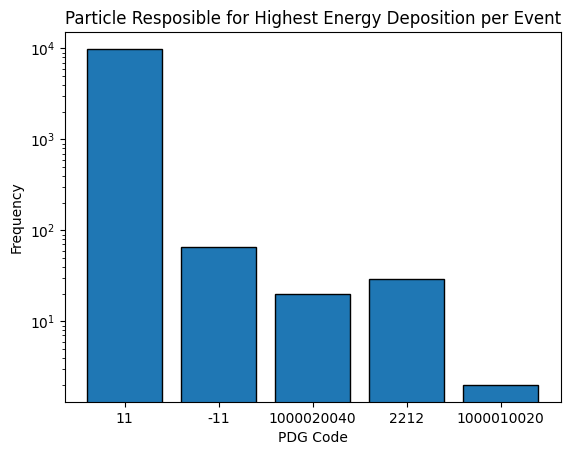

In [59]:
# Particles with highest energy depositions
plt.bar([str(x) for x in edata_particles], [edata_particles[x] for x in edata_particles], edgecolor='black')

# Axis labels
plt.yscale('log')
plt.xlabel('PDG Code')
plt.ylabel('Frequency')
plt.title('Particle Resposible for Highest Energy Deposition per Event')

plt.show()

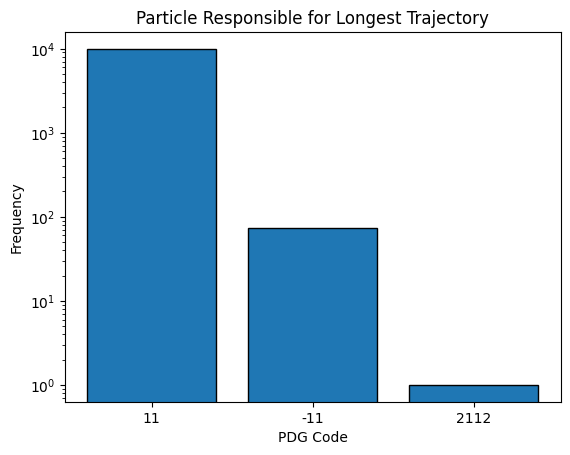

In [58]:
# Particles with longest trajectories
plt.bar([str(x) for x in ldata_particles], [ldata_particles[x] for x in ldata_particles], edgecolor='black')

# Axis labels
plt.yscale('log')
plt.xlabel('PDG Code')
plt.ylabel('Frequency')
plt.title('Particle Responsible for Longest Trajectory')

plt.show()

In [43]:
# Calculate energy deposition ratio for signal and fiducial volumes
fiducial_data = []
signal_data = []

for event_id in data_totalenergy:
    fiducial_data.append(data_totalenergy[event_id][0] / data_totalenergy[event_id][2])
    signal_data.append(data_totalenergy[event_id][1] / data_totalenergy[event_id][2])

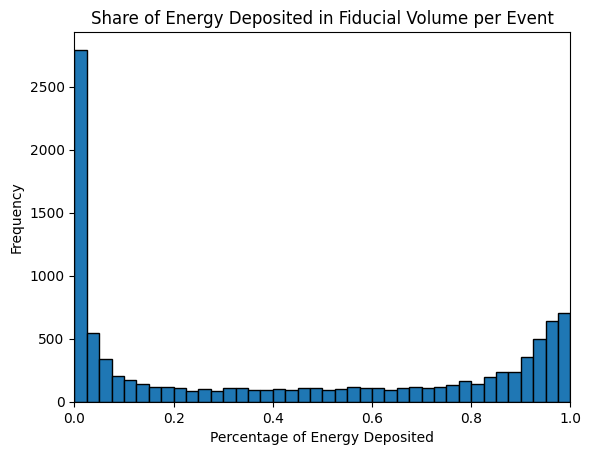

In [60]:
# Fiducial volume ratio plot

# Define bins
bins = np.arange(0, 1.025, 0.025)
plt.hist(fiducial_data, bins=bins, edgecolor='black')
plt.xlim(0, 1)

# Axis labels
plt.xlabel('Percentage of Energy Deposited')
plt.ylabel('Frequency')
plt.title('Share of Energy Deposited in Fiducial Volume per Event')

plt.show()

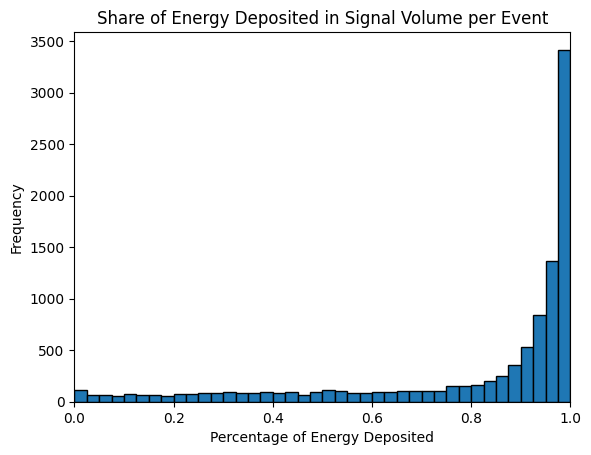

In [61]:
# Signal volume ratio plot

# Define bins
bins = np.arange(0, 1.025, 0.025)
plt.hist(signal_data, bins=bins, edgecolor='black')
plt.xlim(0, 1)

# Axis labels
plt.xlabel('Percentage of Energy Deposited')
plt.ylabel('Frequency')
plt.title('Share of Energy Deposited in Signal Volume per Event')

plt.show()